<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/notebooks/kan_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Знакомство с pykan: установка и базовые туториалы

In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-gw_uddor
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-gw_uddor
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=e730188f5fca60def44a4227010e767dd98206ccfeb6f8dee6702ed6412d6955
  Stored in directory: /tmp/pip-ephem-wheel-cache-f_8trpy_/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan


Импорт библиотек

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kan import KAN

Пример 0: проверка работы pykan

checkpoint directory created: ./model
saving model version 0.0



description:   0%|                                                           | 0/50 [00:00<?, ?it/s]
| train_loss: 1.03e-01 | test_loss: 1.17e-01 | reg: 0.00e+00 | :   0%|       | 0/50 [00:00<?, ?it/s]
| train_loss: 1.03e-01 | test_loss: 1.17e-01 | reg: 0.00e+00 | :   2%| | 1/50 [00:00<00:09,  5.32it/
| train_loss: 1.02e-01 | test_loss: 1.13e-01 | reg: 0.00e+00 | :   2%| | 1/50 [00:00<00:09,  5.32it/
| train_loss: 1.02e-01 | test_loss: 1.13e-01 | reg: 0.00e+00 | :   4%| | 2/50 [00:00<00:06,  7.03it/
| train_loss: 1.02e-01 | test_loss: 1.13e-01 | reg: 0.00e+00 | :   4%| | 2/50 [00:00<00:06,  7.03it/
| train_loss: 1.02e-01 | test_loss: 1.13e-01 | reg: 0.00e+00 | :   4%| | 2/50 [00:00<00:06,  7.03it/
| train_loss: 1.02e-01 | test_loss: 1.13e-01 | reg: 0.00e+00 | :   4%| | 2/50 [00:00<00:06,  7.03it/
| train_loss: 1.02e-01 | test_loss: 1.13e-01 | reg: 0.00e+00 | :  10%| | 5/50 [00:00<00:02, 15.41it/
| train_loss: 1.02e-01 | test_loss: 1.13e-01 | reg: 0.00e+00 | :  10%| | 5/50 [00:00<00:02

saving model version 0.1
Test MSE: 0.012884


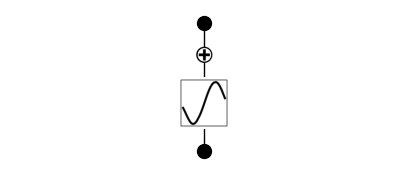

In [ ]:
# Генерация данных: y = sin(x) + шум
N = 300  # всего точек
x = torch.linspace(-3, 3, N).reshape(-1, 1)
y = torch.sin(x) + 0.1 * torch.randn_like(x)

# Перемешивание и разбивка данных на train (80%) и test (20%)
N_train = int(0.8 * N)  # 240 точек
indices = torch.randperm(N)  # случайный порядок

train_indices = indices[:N_train]
test_indices = indices[N_train:]

train_x = x[train_indices]
train_y = y[train_indices]
test_x = x[test_indices]
test_y = y[test_indices]

# Соборка датасета
dataset = {
    'train_input': train_x,
    'train_label': train_y,
    'test_input': test_x,
    'test_label': test_y
}

# Создание и обучение KAN
model = KAN(width=[1, 1], grid=5, k=3)
model.fit(dataset=dataset, opt="LBFGS", steps=50)

# Визуализация
model.plot()

# Как модель предсказывает на тесте
with torch.no_grad():
    pred_train = model(train_x)
    pred_test = model(test_x)

# Ошибка на тесте
test_loss = torch.mean((pred_test - test_y)**2)
print(f"Test MSE: {test_loss.item():.6f}")

Пример 1: Регрессия функции sin(x) с шумом - Туториал "hellokan"

cpu
checkpoint directory created: ./model
saving model version 0.0



description:   0%|                                                          | 0/100 [00:00<?, ?it/s]
| train_loss: 1.41e-01 | test_loss: 1.37e-01 | reg: 7.61e+00 | :   0%|      | 0/100 [00:00<?, ?it/s]
| train_loss: 1.41e-01 | test_loss: 1.37e-01 | reg: 7.61e+00 | :   1%| | 1/100 [00:00<01:25,  1.16it
| train_loss: 4.42e-02 | test_loss: 4.11e-02 | reg: 8.09e+00 | :   1%| | 1/100 [00:01<01:25,  1.16it
| train_loss: 4.42e-02 | test_loss: 4.11e-02 | reg: 8.09e+00 | :   2%| | 2/100 [00:01<01:11,  1.37it
| train_loss: 3.07e-02 | test_loss: 3.14e-02 | reg: 7.89e+00 | :   2%| | 2/100 [00:02<01:11,  1.37it
| train_loss: 3.07e-02 | test_loss: 3.14e-02 | reg: 7.89e+00 | :   3%| | 3/100 [00:02<01:10,  1.37it
| train_loss: 2.49e-02 | test_loss: 2.54e-02 | reg: 7.52e+00 | :   3%| | 3/100 [00:02<01:10,  1.37it
| train_loss: 2.49e-02 | test_loss: 2.54e-02 | reg: 7.52e+00 | :   4%| | 4/100 [00:02<01:06,  1.45it
| train_loss: 2.49e-02 | test_loss: 2.55e-02 | reg: 6.81e+00 | :   4%| | 4/100 [00:03<01:0

saving model version 0.1



description:   0%|                                                          | 0/100 [00:00<?, ?it/s]
| train_loss: 8.56e-03 | test_loss: 8.12e-03 | reg: 0.00e+00 | :   0%|      | 0/100 [00:00<?, ?it/s]
| train_loss: 8.56e-03 | test_loss: 8.12e-03 | reg: 0.00e+00 | :   1%| | 1/100 [00:00<00:29,  3.36it
| train_loss: 8.49e-03 | test_loss: 8.00e-03 | reg: 0.00e+00 | :   1%| | 1/100 [00:00<00:29,  3.36it
| train_loss: 8.49e-03 | test_loss: 8.00e-03 | reg: 0.00e+00 | :   2%| | 2/100 [00:00<00:28,  3.39it
| train_loss: 8.33e-03 | test_loss: 7.99e-03 | reg: 0.00e+00 | :   2%| | 2/100 [00:00<00:28,  3.39it
| train_loss: 8.33e-03 | test_loss: 7.99e-03 | reg: 0.00e+00 | :   3%| | 3/100 [00:00<00:28,  3.45it
| train_loss: 8.26e-03 | test_loss: 7.94e-03 | reg: 0.00e+00 | :   3%| | 3/100 [00:01<00:28,  3.45it
| train_loss: 8.26e-03 | test_loss: 7.94e-03 | reg: 0.00e+00 | :   4%| | 4/100 [00:01<00:26,  3.66it
| train_loss: 8.25e-03 | test_loss: 7.94e-03 | reg: 0.00e+00 | :   4%| | 4/100 [00:01<00:2

saving model version 0.2


description:   0%|                                                           | 0/20 [43:45<?, ?it/s]


fixing (0,0,0) with cos, r2=0.9997814082223196, c=2
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with 0, r2=0.0, c=0
fixing (0,0,3) with 0, r2=0.0, c=0
fixing (0,0,4) with 0, r2=0.0, c=0
fixing (0,1,0) with cos, r2=0.9999970987748577, c=2
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,1,2) with 0, r2=0.0, c=0
fixing (0,1,3) with 0, r2=0.0, c=0
fixing (0,1,4) with 0, r2=0.0, c=0
fixing (1,0,0) with exp, r2=0.9999879064359901, c=2
fixing (1,1,0) with 0, r2=0.0, c=0
fixing (1,2,0) with 0, r2=0.0, c=0
fixing (1,3,0) with 0, r2=0.0, c=0
fixing (1,4,0) with 0, r2=0.0, c=0
saving model version 0.3


/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))
| train_loss: nan | test_loss: nan | reg: 0.00e+00 | :   5%|▍       | 5/100 [00:02<00:53,  1.79it/s]

lstsq failed


UnboundLocalError: cannot access local variable 'coef' where it is not associated with a value

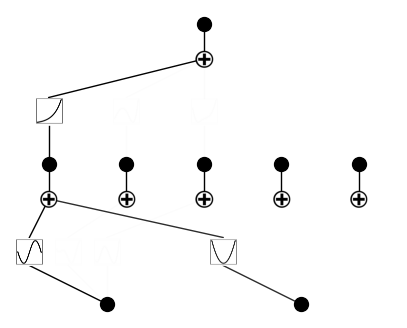

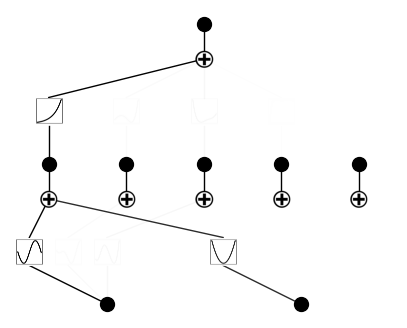

In [ ]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

from kan.utils import create_dataset

f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape


model.fit(dataset, opt="LBFGS", steps=100, lamb=0.001, lamb_entropy=0.001)

model.plot()


model.fit(dataset, opt="LBFGS", steps=100, grid_update_num=10)

model.plot()

model.auto_symbolic()
model.symbolic_formula()

# model.fit(dataset, opt="LBFGS", steps=100) - возможно дообучение
model.symbolic_formula()

Пример 2: Регрессия и символическая регрессия для f(x,y) = exp(sin(πx) + y²) - Туториал "Example_1_function_fitting"